# Week 8
## Overview

It's the last time we meet in class for exercises! And to celebrate this mile-stone, I've put together an very nice little set of exercises. And if you're behind, don't worry. The workload is low!

  - Part A: First, we play around with sentiment analysis
  - That's it!


# Part A: Sentiment analysis

Sentiment analysis is another highly useful technique which we'll use to make sense of the Wiki
data. Further, experience shows that it might well be very useful when you get to the project stage of the class.



> **Video Lecture**: Uncle Sune talks about sentiment and his own youthful adventures.



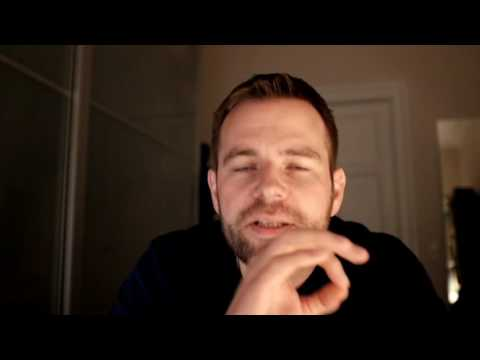

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("JuYcaYYlfrI",width=800, height=450)

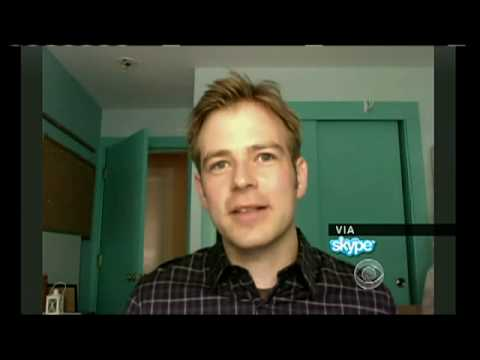

In [2]:
# There's also this one from 2010 with young Sune's research
YouTubeVideo("hY0UCD5UiiY",width=800, height=450)

> Reading: [Temporal Patterns of Happiness and Information in a Global Social Network: Hedonometrics and Twitter](http://journals.plos.org/plosone/article?id=10.1371/journal.pone.0026752) 


*Exercise*: Sentiment distribution. 
> 
> * Download the LabMT wordlist. It's available as supplementary material from [Temporal Patterns of Happiness and Information in a Global Social Network: Hedonometrics and Twitter](http://journals.plos.org/plosone/article?id=10.1371/journal.pone.0026752) (Data Set S1). Describe briefly how the list was generated.
> * Based on the LabMT word list, write a function that calculates sentiment given a list of tokens (the tokens should be lower case, etc).


In [ ]:
# This file is tab separated, so we can use pandas to read it
import pandas as pd

# Read the LabMT wordlist
# Skip the first 3 lines (title, subtitle, empty line), then read the header
labmt_data = pd.read_csv('/Users/maks/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/DTU/11. semester/02805 Social graphs and interactions/socialgraphs2025/lectures/data/Data_Set_S1.txt', 
                         sep='\t', 
                         skiprows=3)    
labmt_data.head()

,word,happiness_rank,happiness_average,happiness_standard_deviation,twitter_rank,google_rank,nyt_rank,lyrics_rank
0,laughter,1,8.50,0.9313,3600,--,--,1728
1,happiness,2,8.44,0.9723,1853,2458,--,1230
2,love,3,8.42,1.1082,25,317,328,23
3,happy,4,8.30,0.9949,65,1372,1313,375
4,laughed,5,8.26,1.1572,3334,3542,--,2332


In [46]:
# Create sentiment dictionaries with both average and standard deviation
sentiment_avg = dict(zip(labmt_data['word'], labmt_data['happiness_average']))
sentiment_std = dict(zip(labmt_data['word'], labmt_data['happiness_standard_deviation']))

print(f"Loaded {len(sentiment_avg)} words with sentiment scores")
print(f"Sentiment scores range from {labmt_data['happiness_average'].min():.2f} to {labmt_data['happiness_average'].max():.2f}")
print(f"Standard deviation range from {labmt_data['happiness_standard_deviation'].min():.2f} to {labmt_data['happiness_standard_deviation'].max():.2f}")
print(f"\nExample words (avg, std):")
print(f"  'happy': {sentiment_avg.get('happy', 'N/A')}, {sentiment_std.get('happy', 'N/A')}")
print(f"  'sad': {sentiment_avg.get('sad', 'N/A')}, {sentiment_std.get('sad', 'N/A')}")
print(f"  'love': {sentiment_avg.get('love', 'N/A')}, {sentiment_std.get('love', 'N/A')}")


Loaded 10222 words with sentiment scores
Sentiment scores range from 1.30 to 8.50
Standard deviation range from 0.40 to 2.93

Example words (avg, std):
  'happy': 8.3, 0.9949
  'sad': 2.38, 1.6149
  'love': 8.42, 1.1082


In [ ]:
def calculate_text_sentiment(text, sentiment_dict=sentiment_avg):
    """
    Tokenize given text and calculate the average sentiment score using the LabMT wordlist.

    Parameters:
        text (str): The input text to analyze.
        sentiment_dict (dict): Mapping from word -> sentiment value (default: happiness_average).
    
    Returns:
        tuple: (tokens, average sentiment value over found tokens, or None if no matches)
    """
    from nltk.tokenize import word_tokenize

    # Tokenize and filter
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if token.isalpha()]
    
    # Collect sentiment values for tokens that exist in the sentiment_dict
    values = [sentiment_dict[token] for token in tokens if token in sentiment_dict]
    # If we found sentiment values, calculate the mean
    if values:
        sentiment = sum(values) / len(values)
    else:
        sentiment = None
    return tokens, sentiment

# Example usage
text = "The Beatles were an amazing rock band that brought joy to millions!"
tokens, sentiment = calculate_text_sentiment(text)
print(f"\nText: {text}")
print(f"Tokens: {tokens}")
print(f"Sentiment: {sentiment:.3f}" if sentiment is not None else "Sentiment: None")

# Adding a test case
test_text = "I love this wonderful and amazing day! It brings such joy and happiness to everyone."
tokens, sentiment = calculate_text_sentiment(test_text)
print(f"\nText: {test_text}")
print(f"Tokens: {tokens}")
print(f"Sentiment: {sentiment:.3f}" if sentiment is not None else "Sentiment: None")



Text: The Beatles were an amazing rock band that brought joy to millions!
Tokens: ['the', 'beatles', 'were', 'an', 'amazing', 'rock', 'band', 'that', 'brought', 'joy', 'to', 'millions']
Sentiment: 6.048

Text: I love this wonderful and amazing day! It brings such joy and happiness to everyone.
Tokens: ['i', 'love', 'this', 'wonderful', 'and', 'amazing', 'day', 'it', 'brings', 'such', 'joy', 'and', 'happiness', 'to', 'everyone']
Sentiment: 6.345


> * Iterate over the nodes in your network, tokenize each page, and calculate sentiment every single page. Now you have sentiment as a new nodal property.


In [ ]:
import networkx as nx
import pickle
import os

# Load the graph
gpickle_path = 'data/G.gpickle'
performer_pages_dir = 'data/performer_pages'

if os.path.exists(gpickle_path):
    with open(gpickle_path, 'rb') as f:
        G = pickle.load(f)

    print(f"Loaded network with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    
    # Iterate over all nodes, read text from files, and calculate sentiment
    successful = 0
    failed = 0
    
    for node in G.nodes():
        # Construct filename from node name
        filename = f"{node}.txt"
        filepath = os.path.join(performer_pages_dir, filename)
        
        # Try to read the text file
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                text = f.read()
            
            # Tokenize and calculate sentiment
            tokens, sentiment = calculate_text_sentiment(text)
            
            # Store sentiment as node property
            G.nodes[node]['sentiment'] = sentiment
            successful += 1
            
        except FileNotFoundError:
            print(f"Warning: File not found for node '{node}'")
            G.nodes[node]['sentiment'] = None
            failed += 1
        except Exception as e:
            print(f"Error processing node '{node}': {e}")
            G.nodes[node]['sentiment'] = None
            failed += 1
    
    print(f"\nProcessed {successful} nodes successfully, {failed} failed.")
    
    # Show example results
    example_nodes = list(G.nodes())[:3]
    print(f"\nExample sentiment scores:")
    for node in example_nodes:
        sentiment = G.nodes[node].get('sentiment')
        print(f"  {node}: {sentiment:.3f}" if sentiment else f"  {node}: None")

else:
    print(f"File not found: {gpickle_path}")
    print("Please make sure the graph file is present in the 'data' folder.")


Loaded network with 485 nodes and 6383 edges.

Processed 484 nodes successfully, 1 failed.

Example sentiment scores:
  10_Years_(band): 5.623
  10cc: 5.543
  311_(band): 5.647


> * Calculate the average sentiment across all the pages. Also calculate the median, variance, 25th percentile, 75th percentile.

In [52]:
import numpy as np

# Collect all sentiment values, filtering out None values
sentiments = [
    data['sentiment']
    for node, data in G.nodes(data=True)
    if data.get('sentiment') is not None
]

if sentiments:
    sentiments_arr = np.array(sentiments)
    mean_sentiment = np.mean(sentiments_arr)
    median_sentiment = np.median(sentiments_arr)
    var_sentiment = np.var(sentiments_arr)
    q25_sentiment = np.percentile(sentiments_arr, 25)
    q75_sentiment = np.percentile(sentiments_arr, 75)

    print(f"Sentiment statistics across all pages:")
    print(f"  Mean: {mean_sentiment:.3f}")
    print(f"  Median: {median_sentiment:.3f}")
    print(f"  Variance: {var_sentiment:.5f}")
    print(f"  25th percentile: {q25_sentiment:.3f}")
    print(f"  75th percentile: {q75_sentiment:.3f}")
else:
    print("No valid sentiment data found.")


Sentiment statistics across all pages:
  Mean: 5.577
  Median: 5.579
  Variance: 0.00511
  25th percentile: 5.538
  75th percentile: 5.621


> * Remember histograms? Create a histogram of all of the artists's associated page-sentiments. (And make it a nice histogram - use your histogram making skills from Week 2). Add the mean, meadian, ect from above to your plot.

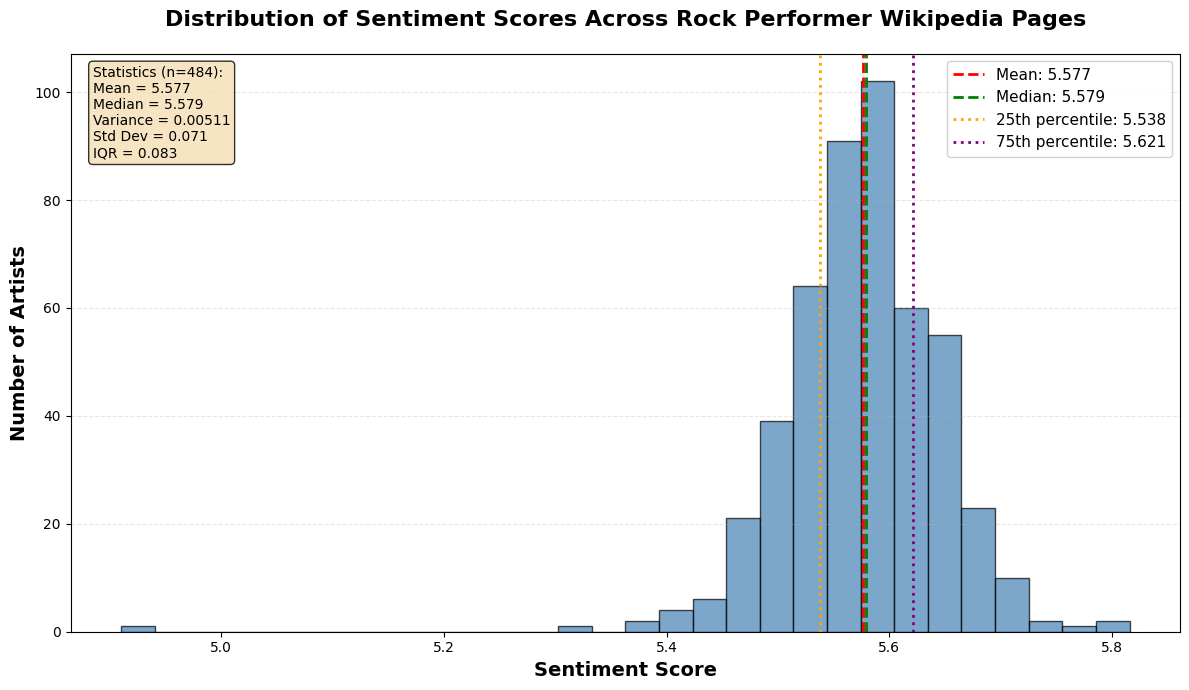


Histogram shows the distribution of sentiment scores for 484 rock performers.


In [56]:
import matplotlib.pyplot as plt

# Create a beautiful histogram of sentiment scores
fig, ax = plt.subplots(figsize=(12, 7))

# Plot histogram
n, bins, patches = ax.hist(sentiments, bins=30, edgecolor='black', alpha=0.7, color='steelblue')

# Add vertical lines for statistics
ax.axvline(mean_sentiment, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_sentiment:.3f}')
ax.axvline(median_sentiment, color='green', linestyle='--', linewidth=2, label=f'Median: {median_sentiment:.3f}')
ax.axvline(q25_sentiment, color='orange', linestyle=':', linewidth=2, label=f'25th percentile: {q25_sentiment:.3f}')
ax.axvline(q75_sentiment, color='purple', linestyle=':', linewidth=2, label=f'75th percentile: {q75_sentiment:.3f}')

# Add labels and title
ax.set_xlabel('Sentiment Score', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Artists', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Sentiment Scores Across Rock Performer Wikipedia Pages', 
             fontsize=16, fontweight='bold', pad=20)

# Add legend
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Add grid for easier reading
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add text box with statistics
stats_text = f'Statistics (n={len(sentiments)}):\n'
stats_text += f'Mean = {mean_sentiment:.3f}\n'
stats_text += f'Median = {median_sentiment:.3f}\n'
stats_text += f'Variance = {var_sentiment:.5f}\n'
stats_text += f'Std Dev = {np.sqrt(var_sentiment):.3f}\n'
stats_text += f'IQR = {q75_sentiment - q25_sentiment:.3f}'

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Make it look professional
plt.tight_layout()
plt.show()

print(f"\nHistogram shows the distribution of sentiment scores for {len(sentiments)} rock performers.")


> * Who are the 10 artists with happiest and saddest pages?

In [59]:
# Find the 10 happiest and 10 saddest artists
# Create a list of (artist, sentiment) tuples, filtering out None values
artist_sentiments = [
    (node, data['sentiment'])
    for node, data in G.nodes(data=True)
    if data.get('sentiment') is not None
]

# Sort by sentiment
artist_sentiments_sorted = sorted(artist_sentiments, key=lambda x: x[1])

# Get top 10 saddest and happiest
saddest_10 = artist_sentiments_sorted[:10]
happiest_10 = artist_sentiments_sorted[-10:][::-1]  # Reverse to show highest first

print("=" * 60)
print("TOP 10 HAPPIEST ARTISTS:")
print("=" * 60)
for i, (artist, sentiment) in enumerate(happiest_10, 1):
    print(f"{i:2d}. {artist:45s} {sentiment:.4f}")

print("\n" + "=" * 60)
print("TOP 10 SADDEST ARTISTS:")
print("=" * 60)
for i, (artist, sentiment) in enumerate(saddest_10, 1):
    print(f"{i:2d}. {artist:45s} {sentiment:.4f}")


TOP 10 HAPPIEST ARTISTS:
 1. Tracy_Chapman                                 5.8158
 2. Lenny_Kravitz                                 5.8032
 3. Boys_Like_Girls                               5.7834
 4. Fun_(band)                                    5.7454
 5. AllMusic                                      5.7367
 6. Kenny_Loggins                                 5.7174
 7. Living_Colour                                 5.7134
 8. Michael_Martin_Murphey                        5.7084
 9. Air_Supply                                    5.7081
10. The_Cardigans                                 5.7059

TOP 10 SADDEST ARTISTS:
 1. Poison_(American_band)                        4.9100
 2. Five_Finger_Death_Punch                       5.3250
 3. Rage_Against_the_Machine                      5.3723
 4. Rob_Zombie                                    5.3772
 5. Marilyn_Manson                                5.4082
 6. Quiet_Riot                                    5.4094
 7. Canned_Heat                       


<div class="alert alert-block alert-info">
As long as you get the plots right, it's OK to use LLM help here.
</div>

*Exercise*: Community sentiment distribution. 
  
> * Last week we calculated the stuctural communities of the graph. For this exercise, we use those communities (just the 10 largest ones). Specifically, you should calculate the average the average sentiment of the nodes in each community to find a *community level sentiment*. 
>   - Name each community by its three most connected bands. (Or feed the list of bands in each community and ask the LLM to come up with a good name for the community).
>   - What are the three happiest communities? 
>   - what are the three saddest communities?
>   - Do these results confirm what you can learn about each community by comparing to the genres, checking out the word-clouds for each community, and reading the wiki-pages? 
> * Compare the sentiment of the happiest and saddest communities to the overall (entire network) distribution of sentiment that you calculated in the previous exercise. Are the communities very differenct from the average? Or do you find the sentiment to be quite similar across all of the communities?

<div class="alert alert-block alert-info">
As above, feel free to go nuts with help from an LLM with this exercise for the technical parts. But try to answer the questions about interpreting the results with your own human brain.
</div>

**Note**: Calculating sentiment may take a long time, so arm yourself with patience as your code runs (remember to check that it runs correctly, before waiting patiently). Further, these tips may speed things up. And save somewhere, so you don't have to start over.

**Tips for speed**
* If you use `freqDist` prior to finding the sentiment, you only have to find it for every unique word and hereafter you can do a weighted mean.
* More tips for speeding up loops https://wiki.python.org/moin/PythonSpeed/PerformanceTips#Loops